# Step 1: Import libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 2: Load Dataset

In [3]:
df = pd.read_csv("Mall_Customers (3).csv")
                 

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Step 3: Data Preprocessing

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
# Checking missing values
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
# Drop the columns that are not needed for clustering
df.drop(['CustomerID','Gender'],axis=1,inplace=True) # inplace=True means permanently drop the columns from the dataframe


# Step 4: EDA

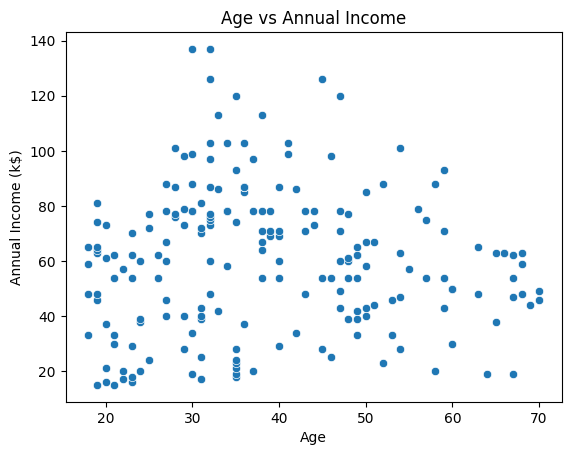

In [10]:
# Display Age and Annual Income (k$) relationship using scatter plot
plt.Figure(figsize=(10,6))
sns.scatterplot(x='Age',y='Annual Income (k$)',data=df)
plt.title("Age vs Annual Income")
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.show()

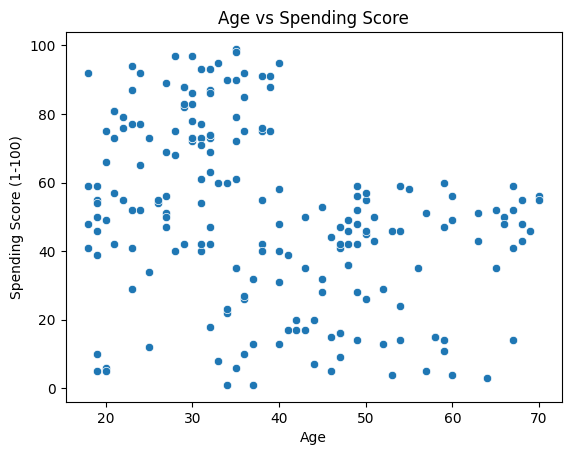

In [11]:
# Display Age and Spending score relationship using scatter plot
plt.Figure(figsize=(10,6))
sns.scatterplot(x='Age',y='Spending Score (1-100)',data=df)
plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.show()

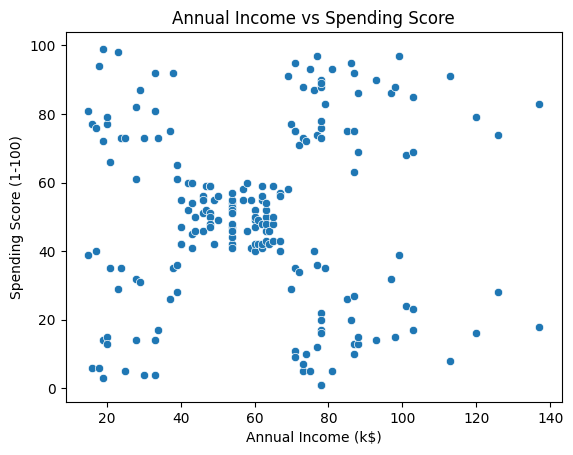

In [12]:
# Display Annual Income and Spending score relationship using scatter plot
plt.Figure(figsize=(10,6))
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',data=df)
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

# Step 5: Feature Engineering

In [13]:
df.skew()

Age                       0.485569
Annual Income (k$)        0.321843
Spending Score (1-100)   -0.047220
dtype: float64

In [16]:
def skewness_names(skewness):
    if skewness > 0:
        return "Right skewed"
    elif skewness < 0:
        return "Left skewed"
    else:
        return "Symmetric"
print("Skewness of Age:",skewness_names(df['Age'].skew()))
print("Skewness of Annual Income (k$):",skewness_names(df['Annual Income (k$)'].skew()))
print("Skewness of Spending Score (1-100):",skewness_names(df['Spending Score (1-100)'].skew()))

Skewness of Age: Right skewed
Skewness of Annual Income (k$): Right skewed
Skewness of Spending Score (1-100): Left skewed


In [19]:
# Scaling the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_data = pd.DataFrame(scaled_data,columns=df.columns)
scaled_data

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
...,...,...,...
195,-0.276302,2.268791,1.118061
196,0.441365,2.497807,-0.861839
197,-0.491602,2.497807,0.923953
198,-0.491602,2.917671,-1.250054


# Step 6: Train K-Mean Model

In [34]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5,random_state=42)
kmeans.fit(scaled_data)
df['Cluster'] = kmeans.labels_
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,19,15,39,4
1,21,15,81,4
2,20,16,6,2
3,23,16,77,4
4,31,17,40,4


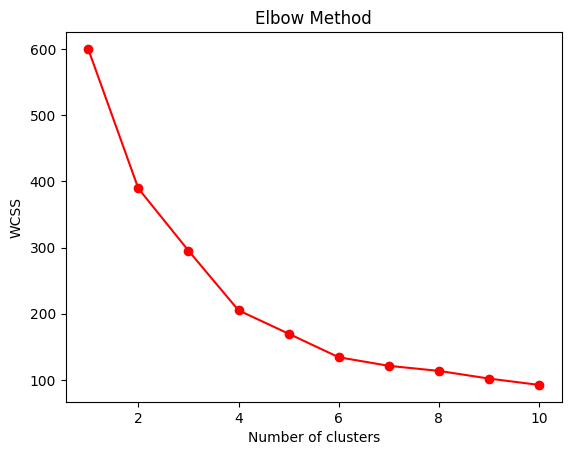

In [35]:
# check with elbow method
wcss=[]
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(scaled_data.drop('Cluster',axis=1))
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss,marker='o',color = 'red')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

# Display Cluster

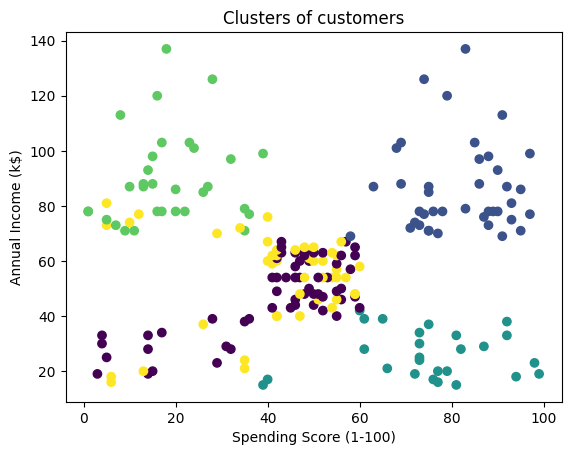

In [36]:
plt.scatter(df['Spending Score (1-100)'],df['Annual Income (k$)'],c=scaled_data['Cluster'],cmap='viridis')
plt.title("Clusters of customers")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Annual Income (k$)")
plt.show()

In [37]:
# Save the file
df.to_csv("Clustered_Mall_Customers.csv",index=False)

In [38]:
clus = pd.read_csv("Clustered_Mall_Customers.csv")


In [39]:
clus.head()

,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,19,15,39,4
1,21,15,81,4
2,20,16,6,2
3,23,16,77,4
4,31,17,40,4


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

x = clus.drop('Cluster', axis=1)
y = clus['Cluster'].values  # Convert to NumPy array
y = y.astype(int)  # Ensure it's numeric

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [46]:
import joblib
joblib.dump(model, "cluster_model.pkl")

['cluster_model.pkl']